In [1]:
import cv2
import matplotlib.pyplot as plt

In [2]:
image1 = cv2.imread("pexels-alexravvas-26611787.jpg")
image2 = cv2.imread("pexels-alexravvas-26611787.jpg")

In [3]:
gray1 = cv2.cvtColor(cv2.resize(image1, (400, 400)), cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(cv2.resize(image2, (400, 400)),  cv2.COLOR_BGR2GRAY)


In [4]:
sift = cv2.SIFT_create()
keypoints1 = sift.detect(gray1, None)
keypoints2 = sift.detect(gray2, None)

print(f"keypoints in image1: {len(keypoints1)}")
print(f"keypoints in image2: {len(keypoints2)}")

keypoints in image1: 1030
keypoints in image2: 1030


In [5]:
imagekp1 = cv2.drawKeypoints(gray1, keypoints1, gray1)
imagekp2 = cv2.drawKeypoints(gray2, keypoints2, gray2, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

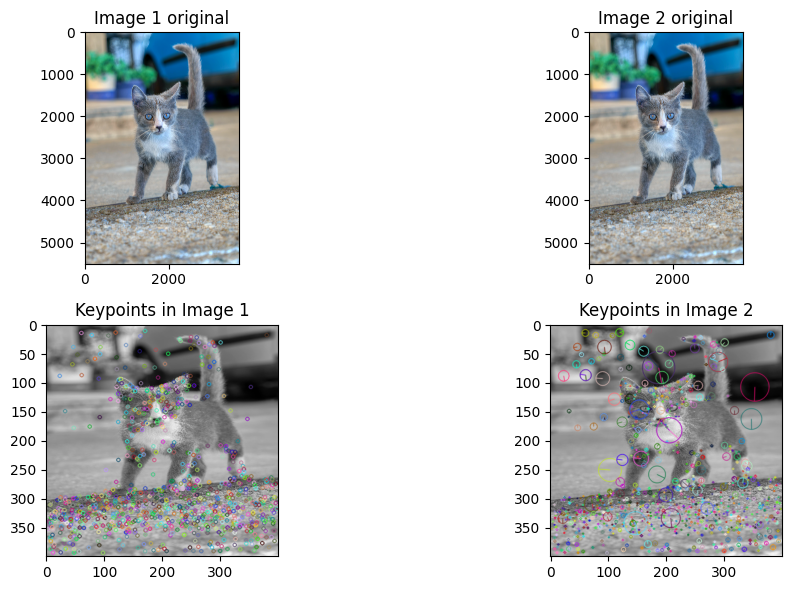

In [6]:
plt.figure(figsize=(12, 6))
plt.subplot(2, 2, 1)
plt.imshow(image1)
plt.title('Image 1 original')


plt.subplot(2, 2, 2)
plt.imshow(image2)
plt.title('Image 2 original')

plt.subplot(2, 2, 3)
plt.imshow(imagekp1)        
plt.title('Keypoints in Image 1')

plt.subplot(2, 2, 4)
plt.imshow(imagekp2)
plt.title('Keypoints in Image 2')

plt.tight_layout()
plt.show()

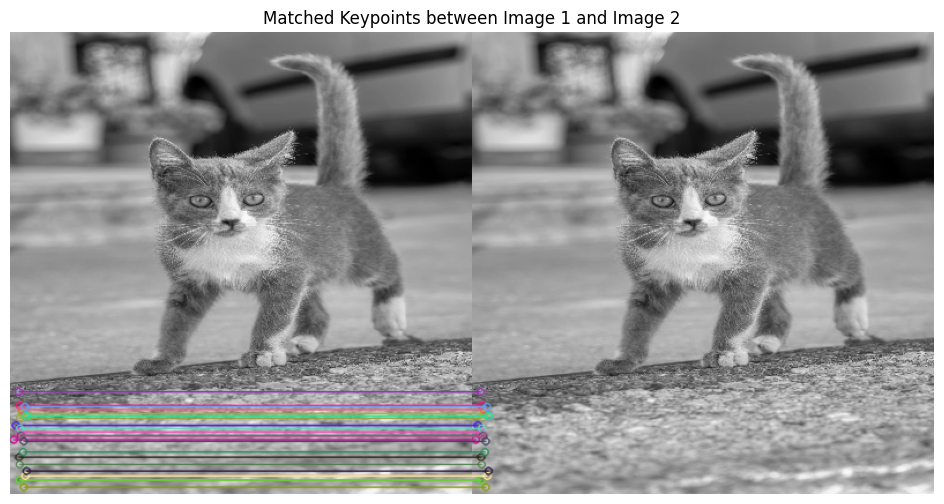

In [7]:
kp1, des1 = sift.compute(gray1, keypoints1)
kp2, des2 = sift.compute(gray2, keypoints2)

# feature mapping
bf  = cv2.BFMatcher(cv2.NORM_L1) # NORM_L1 for SIFT # Norm_L2 for SURF
matches = bf.match(des1, des2)

matches = sorted(matches, key=lambda x: x.distance)

matched_image = cv2.drawMatches(gray1, kp1, gray2, kp2, matches[:25], None, flags=2)

plt.figure(figsize=(12, 6))
plt.imshow(matched_image)
plt.title('Matched Keypoints between Image 1 and Image 2')
plt.axis('off')
plt.show()



In [8]:
surf = cv2.xfeatures2d.SURF_create()
keypoints1_surf, des1_surf = surf.detectAndCompute(gray1, None)
keypoints2_surf, des2_surf = surf.detectAndCompute(gray2, None)

print(f"keypoints in image1 using SURF: {len(keypoints1_surf)}")
print(f"keypoints in image2 using SURF: {len(keypoints2_surf)}")

AttributeError: module 'cv2' has no attribute 'xfeatures2d'

In [ ]:
surf.upright = True # Disable orientation assignment to make it rotation invariant
keypoints1_surf_upright, des1_surf_upright = surf.detectAndCompute(gray1, None)
keypoints2_surf_upright, des2_surf_upright = surf.detectAndCompute(gray2, None)

surf.extended = True # Enable extended descriptor to get 128-dimensional descriptors
keypoints1_surf_extended, des1_surf_extended = surf.detectAndCompute(gray1, None)
keypoints2_surf_extended, des2_surf_extended = surf.detectAndCompute(gray2, None)


bf_surf = cv2.BFMatcher(cv2.NORM_L2) # NORM_L2 for SURF
matches_surf = bf_surf.match(des1_surf, des2_surf)
matches_surf = sorted(matches_surf, key=lambda x: x.distance)
matched_image_surf = cv2.drawMatches(image1, keypoints1_surf, image2, keypoints2_surf, matches_surf[:50], None, flags=2)
plt.figure(figsize=(12, 6))
plt.imshow(matched_image_surf)
plt.title('Matched Keypoints between Image 1 and Image 2 using SURF')
plt.axis('off')
plt.show()
